## 1. Import Required Libraries

# Velvetfruit Product Analysis
Analyzing velvetfruit product prices and trades data across three trading days.

In [22]:
%pip install pandas
%pip install scipy
%pip install matplotlib
%pip install seaborn
%pip install plotly
%pip install nbformat
%pip install statsmodels

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# Set style for plotsplt.rcParams['figure.figsize'] = (12, 6)
sns.set_style("whitegrid")

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 13.4 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [statsmodels] [statsmodels]
Note: you may need to restart the kernel to use updated packages.


## 2. Load Data Files

In [13]:
# Specify the data directory
data_dir = '/Users/raghav/Downloads/Prosperity_2026/eda'

# Load ONLY day 0 files
prices_df = pd.read_csv(os.path.join(data_dir, 'prices_round_3_day_0.csv'), sep=';')
trades_df = pd.read_csv(os.path.join(data_dir, 'trades_round_3_day_0.csv'), sep=';')

print(f"Prices data shape: {prices_df.shape}")
print(f"Trades data shape: {trades_df.shape}")


Prices data shape: (120000, 17)
Trades data shape: (1308, 7)


## 3. Display Loaded Data

In [15]:
# Ignore VEV products, focus only on the base delta-1 products
target_products = ['HYDROGEL_PACK', 'VELVETFRUIT_EXTRACT']

vf_prices = prices_df[prices_df['product'].isin(target_products)].copy()
vf_trades = trades_df[trades_df['symbol'].isin(target_products)].copy()

# Sort to guarantee chronological integrity before finding the diff
vf_prices.sort_values(by=['timestamp'], inplace=True)
vf_trades.sort_values(by=['timestamp'], inplace=True)


## 4. Filter Product Data

In [16]:
# Filter for VELVETFRUIT_EXTRACT only
velvetfruit_prices = prices_df[prices_df['product'].str.contains('VELVETFRUIT_EXTRACT', case=False, na=False)].copy()
velvetfruit_trades = trades_df[trades_df['symbol'].str.contains('VELVETFRUIT_EXTRACT', case=False, na=False)].copy()

print(f"Velvetfruit prices data shape: {velvetfruit_prices.shape}")
print(f"Velvetfruit trades data shape: {velvetfruit_trades.shape}")

print("\n=== Velvetfruit Products ===")
print(velvetfruit_prices['product'].unique())

print("\n=== Velvetfruit Price Data Sample ===")
print(velvetfruit_prices.head(10))

Velvetfruit prices data shape: (10000, 17)
Velvetfruit trades data shape: (445, 7)

=== Velvetfruit Products ===
<StringArray>
['VELVETFRUIT_EXTRACT']
Length: 1, dtype: str

=== Velvetfruit Price Data Sample ===
     day  timestamp              product  bid_price_1  bid_volume_1  \
5      0          0  VELVETFRUIT_EXTRACT         5247            67   
13     0        100  VELVETFRUIT_EXTRACT         5248            69   
25     0        200  VELVETFRUIT_EXTRACT         5248            20   
47     0        300  VELVETFRUIT_EXTRACT         5248            24   
55     0        400  VELVETFRUIT_EXTRACT         5248            25   
61     0        500  VELVETFRUIT_EXTRACT         5247            25   
73     0        600  VELVETFRUIT_EXTRACT         5246            17   
95     0        700  VELVETFRUIT_EXTRACT         5246            24   
103    0        800  VELVETFRUIT_EXTRACT         5245            25   
109    0        900  VELVETFRUIT_EXTRACT         5244            15   

     b

## 7. Correlation Analysis with Hydrogel (Various Lags)

In [17]:
# Load and prepare Hydrogel data
hydrogel_prices = prices_df[prices_df['product'].str.contains('HYDROGEL', case=False, na=False)].copy()

print(f"Hydrogel prices data shape: {hydrogel_prices.shape}")
print(f"\n=== Hydrogel Products ===")
print(hydrogel_prices['product'].unique())

# Aggregate both products by timestamp (take mean if multiple products/entries per timestamp)
velvetfruit_agg = velvetfruit_prices.groupby('timestamp')['mid_price'].mean().reset_index()
velvetfruit_agg.columns = ['timestamp', 'velvetfruit_midprice']

hydrogel_agg = hydrogel_prices.groupby('timestamp')['mid_price'].mean().reset_index()
hydrogel_agg.columns = ['timestamp', 'hydrogel_midprice']

# Merge on timestamp
merged = pd.merge(velvetfruit_agg, hydrogel_agg, on='timestamp', how='inner')
merged = merged.sort_values('timestamp').reset_index(drop=True)

print(f"\n=== Merged Data Shape: {merged.shape} ===")
print(f"Timestamp range: {merged['timestamp'].min()} to {merged['timestamp'].max()}")

# Calculate correlation at various lag values (including negative lags)
# Negative lag: velvetfruit leads (velvetfruit is shifted back)
# Positive lag: hydrogel leads (hydrogel is shifted back)
lag_values = [-250, -100, -50, -25, -10, -5, -1, 0, 1, 5, 10, 25, 50, 100, 250]
correlations = []

print("\n=== Correlation Analysis with Various Lags ===")
print("Negative lag: VELVETFRUIT leads HYDROGEL")
print("Positive lag: HYDROGEL leads VELVETFRUIT\n")

for lag in lag_values:
    if lag == 0:
        corr = merged['velvetfruit_midprice'].corr(merged['hydrogel_midprice'])
    elif lag < 0:
        # Negative lag: shift velvetfruit forward (velvetfruit leads)
        shifted = merged.copy()
        shifted['velvetfruit_shifted'] = shifted['velvetfruit_midprice'].shift(lag)
        corr = shifted['velvetfruit_shifted'].corr(shifted['hydrogel_midprice'])
    else:
        # Positive lag: shift hydrogel forward (hydrogel leads)
        shifted = merged.copy()
        shifted['hydrogel_shifted'] = shifted['hydrogel_midprice'].shift(lag)
        corr = shifted['velvetfruit_midprice'].corr(shifted['hydrogel_shifted'])
    
    correlations.append({'lag': lag, 'correlation': corr})
    direction = "VEL→HYD" if lag < 0 else "HYD→VEL" if lag > 0 else "None"
    print(f"Lag {lag:4d} ({direction}): Correlation = {corr:7.4f}")

corr_df = pd.DataFrame(correlations)

# Plot correlation vs lag including negative lags
fig_corr = go.Figure()
fig_corr.add_trace(go.Scatter(
    x=corr_df['lag'],
    y=corr_df['correlation'],
    mode='lines+markers',
    name='Correlation',
    line=dict(color='green', width=2),
    marker=dict(size=8),
    hovertemplate='<b>Lag:</b> %{x}<br><b>Correlation:</b> %{y:.4f}<extra></extra>'
))

# Add vertical line at lag=0
fig_corr.add_vline(x=0, line_dash="dash", line_color="red", annotation_text="No Lag", annotation_position="top right")

fig_corr.update_layout(
    title='VELVETFRUIT_EXTRACT vs HYDROGEL - Correlation by Lag (Negative & Positive)',
    xaxis_title='Lag (negative: VEL leads, positive: HYD leads)',
    yaxis_title='Correlation Coefficient',
    hovermode='x unified',
    height=500,
    template='plotly_white',
    yaxis=dict(range=[-1, 1])
)
fig_corr.show()

print(f"\n=== Summary ===")
max_idx = corr_df['correlation'].abs().idxmax()
print(f"Strongest correlation: {corr_df.loc[max_idx, 'correlation']:.4f} at lag {corr_df.loc[max_idx, 'lag']:.0f}")
print(f"Maximum positive correlation: {corr_df['correlation'].max():.4f} at lag {corr_df.loc[corr_df['correlation'].idxmax(), 'lag']:.0f}")
print(f"Maximum negative correlation: {corr_df['correlation'].min():.4f} at lag {corr_df.loc[corr_df['correlation'].idxmin(), 'lag']:.0f}")

Hydrogel prices data shape: (10000, 17)

=== Hydrogel Products ===
<StringArray>
['HYDROGEL_PACK']
Length: 1, dtype: str

=== Merged Data Shape: (10000, 3) ===
Timestamp range: 0 to 999900

=== Correlation Analysis with Various Lags ===
Negative lag: VELVETFRUIT leads HYDROGEL
Positive lag: HYDROGEL leads VELVETFRUIT

Lag -250 (VEL→HYD): Correlation =  0.5127
Lag -100 (VEL→HYD): Correlation =  0.4800
Lag  -50 (VEL→HYD): Correlation =  0.4956
Lag  -25 (VEL→HYD): Correlation =  0.4982
Lag  -10 (VEL→HYD): Correlation =  0.4991
Lag   -5 (VEL→HYD): Correlation =  0.5004
Lag   -1 (VEL→HYD): Correlation =  0.5002
Lag    0 (None): Correlation =  0.5001
Lag    1 (HYD→VEL): Correlation =  0.5002
Lag    5 (HYD→VEL): Correlation =  0.5004
Lag   10 (HYD→VEL): Correlation =  0.4991
Lag   25 (HYD→VEL): Correlation =  0.4982
Lag   50 (HYD→VEL): Correlation =  0.4956
Lag  100 (HYD→VEL): Correlation =  0.4800
Lag  250 (HYD→VEL): Correlation =  0.5127



=== Summary ===
Strongest correlation: 0.5127 at lag -250
Maximum positive correlation: 0.5127 at lag -250
Maximum negative correlation: 0.4800 at lag -100


## 8. Orderbook Imbalance Analysis

In [18]:
# Calculate orderbook imbalance for both products
def calculate_orderbook_imbalance(prices_data):
    """
    Calculate orderbook imbalance: (bid_volume - ask_volume) / (bid_volume + ask_volume)
    Imbalance range: -1 (all sell) to +1 (all buy)
    """
    bid_cols = [col for col in prices_data.columns if 'bid_volume' in col]
    ask_cols = [col for col in prices_data.columns if 'ask_volume' in col]
    
    # Sum bid and ask volumes
    total_bid_volume = prices_data[bid_cols].sum(axis=1)
    total_ask_volume = prices_data[ask_cols].sum(axis=1)
    
    # Calculate imbalance
    total_volume = total_bid_volume + total_ask_volume
    imbalance = (total_bid_volume - total_ask_volume) / total_volume
    
    return total_bid_volume, total_ask_volume, imbalance

# Calculate imbalance for velvetfruit
vel_bid_vol, vel_ask_vol, vel_imbalance = calculate_orderbook_imbalance(velvetfruit_prices)
velvetfruit_prices['bid_volume_total'] = vel_bid_vol
velvetfruit_prices['ask_volume_total'] = vel_ask_vol
velvetfruit_prices['imbalance'] = vel_imbalance

# Calculate imbalance for hydrogel
hyd_bid_vol, hyd_ask_vol, hyd_imbalance = calculate_orderbook_imbalance(hydrogel_prices)
hydrogel_prices['bid_volume_total'] = hyd_bid_vol
hydrogel_prices['ask_volume_total'] = hyd_ask_vol
hydrogel_prices['imbalance'] = hyd_imbalance

print("=== Orderbook Imbalance Statistics ===\n")
print("VELVETFRUIT_EXTRACT:")
print(f"  Imbalance mean: {velvetfruit_prices['imbalance'].mean():.4f}")
print(f"  Imbalance std: {velvetfruit_prices['imbalance'].std():.4f}")
print(f"  Imbalance min: {velvetfruit_prices['imbalance'].min():.4f}")
print(f"  Imbalance max: {velvetfruit_prices['imbalance'].max():.4f}")

print("\nHYDROGEL_PACK:")
print(f"  Imbalance mean: {hydrogel_prices['imbalance'].mean():.4f}")
print(f"  Imbalance std: {hydrogel_prices['imbalance'].std():.4f}")
print(f"  Imbalance min: {hydrogel_prices['imbalance'].min():.4f}")
print(f"  Imbalance max: {hydrogel_prices['imbalance'].max():.4f}")

# Plot orderbook imbalance for both products over time
fig_imbalance = make_subplots(
    rows=2, cols=1,
    subplot_titles=("VELVETFRUIT_EXTRACT - Orderbook Imbalance", 
                    "HYDROGEL_PACK - Orderbook Imbalance"),
    specs=[[{"secondary_y": False}], [{"secondary_y": False}]]
)

# Sort data by timestamp
vel_sorted = velvetfruit_prices.sort_values('timestamp')
hyd_sorted = hydrogel_prices.sort_values('timestamp')

# Add velvetfruit imbalance trace
fig_imbalance.add_trace(
    go.Scatter(x=vel_sorted['timestamp'], y=vel_sorted['imbalance'],
               mode='lines', name='VELVETFRUIT_EXTRACT',
               line=dict(color='blue', width=1),
               opacity=0.7,
               hovertemplate='<b>Timestamp:</b> %{x}<br><b>Imbalance:</b> %{y:.4f}<extra></extra>'),
    row=1, col=1
)

# Add hydrogel imbalance trace
fig_imbalance.add_trace(
    go.Scatter(x=hyd_sorted['timestamp'], y=hyd_sorted['imbalance'],
               mode='lines', name='HYDROGEL_PACK',
               line=dict(color='orange', width=1),
               opacity=0.7,
               hovertemplate='<b>Timestamp:</b> %{x}<br><b>Imbalance:</b> %{y:.4f}<extra></extra>'),
    row=2, col=1
)

# Add zero line for reference
for row in [1, 2]:
    fig_imbalance.add_hline(y=0, line_dash="dash", line_color="gray", 
                           row=row, col=1, opacity=0.5)

fig_imbalance.update_xaxes(title_text="Timestamp", row=2, col=1)
fig_imbalance.update_yaxes(title_text="Imbalance (-1 to +1)", row=1, col=1)
fig_imbalance.update_yaxes(title_text="Imbalance (-1 to +1)", row=2, col=1)

fig_imbalance.update_layout(
    title_text="Orderbook Imbalance: VELVETFRUIT_EXTRACT vs HYDROGEL_PACK",
    height=800,
    hovermode='x unified',
    template='plotly_white'
)

fig_imbalance.show()

# Create comparison plot on same chart using secondary y-axis
fig_comparison = go.Figure()

fig_comparison.add_trace(go.Scatter(
    x=vel_sorted['timestamp'], y=vel_sorted['imbalance'],
    mode='lines', name='VELVETFRUIT_EXTRACT',
    line=dict(color='blue', width=1),
    opacity=0.6
))

fig_comparison.add_trace(go.Scatter(
    x=hyd_sorted['timestamp'], y=hyd_sorted['imbalance'],
    mode='lines', name='HYDROGEL_PACK',
    line=dict(color='orange', width=1),
    opacity=0.6
))

fig_comparison.add_hline(y=0, line_dash="dash", line_color="red", opacity=0.5)

fig_comparison.update_layout(
    title="Orderbook Imbalance Comparison (Overlaid)",
    xaxis_title="Timestamp",
    yaxis_title="Imbalance (-1: all sell, +1: all buy)",
    height=600,
    hovermode='x unified',
    template='plotly_white',
    yaxis=dict(range=[-1, 1])
)

fig_comparison.show()

print("\n=== Imbalance Interpretation ===")
print("+1: All bid volume (max buying pressure)")
print(" 0: Equal bid and ask volume (neutral)")
print("-1: All ask volume (max selling pressure)")

=== Orderbook Imbalance Statistics ===

VELVETFRUIT_EXTRACT:
  Imbalance mean: -0.0000
  Imbalance std: 0.0195
  Imbalance min: -0.1683
  Imbalance max: 0.1376

HYDROGEL_PACK:
  Imbalance mean: -0.0003
  Imbalance std: 0.0169
  Imbalance min: -0.1429
  Imbalance max: 0.1429



=== Imbalance Interpretation ===
+1: All bid volume (max buying pressure)
 0: Equal bid and ask volume (neutral)
-1: All ask volume (max selling pressure)


## 9. Orderbook Imbalance Correlation Analysis

In [19]:
# Align imbalance data by timestamp for correlation analysis
imbalance_merged = pd.DataFrame({
    'timestamp': velvetfruit_prices['timestamp'],
    'vel_imbalance': velvetfruit_prices['imbalance'].values,
    'hyd_imbalance': hydrogel_prices['imbalance'].values
}).sort_values('timestamp').reset_index(drop=True)

print("=== Orderbook Imbalance Correlation Analysis ===\n")
print(f"Data points: {len(imbalance_merged)}")
print(f"Timestamp range: {imbalance_merged['timestamp'].min()} to {imbalance_merged['timestamp'].max()}\n")

# Calculate correlation at various lag values (including negative lags)
lag_values = [-250, -100, -50, -25, -10, -5, -1, 0, 1, 5, 10, 25, 50, 100, 250]
corr_imbalances = []

print("=== Correlation by Lag ===")
print("Negative lag: VELVETFRUIT leads HYDROGEL")
print("Positive lag: HYDROGEL leads VELVETFRUIT\n")

for lag in lag_values:
    if lag == 0:
        corr = imbalance_merged['vel_imbalance'].corr(imbalance_merged['hyd_imbalance'])
    elif lag < 0:
        # Negative lag: shift velvetfruit forward (velvetfruit leads)
        shifted = imbalance_merged.copy()
        shifted['vel_shifted'] = shifted['vel_imbalance'].shift(lag)
        corr = shifted['vel_shifted'].corr(shifted['hyd_imbalance'])
    else:
        # Positive lag: shift hydrogel forward (hydrogel leads)
        shifted = imbalance_merged.copy()
        shifted['hyd_shifted'] = shifted['hyd_imbalance'].shift(lag)
        corr = shifted['vel_imbalance'].corr(shifted['hyd_shifted'])
    
    corr_imbalances.append({'lag': lag, 'correlation': corr})
    direction = "VEL→HYD" if lag < 0 else "HYD→VEL" if lag > 0 else "None"
    print(f"Lag {lag:4d} ({direction}): Correlation = {corr:7.4f}")

corr_imb_df = pd.DataFrame(corr_imbalances)

# Plot correlation of imbalances vs lag
fig_imb_corr = go.Figure()
fig_imb_corr.add_trace(go.Scatter(
    x=corr_imb_df['lag'],
    y=corr_imb_df['correlation'],
    mode='lines+markers',
    name='Imbalance Correlation',
    line=dict(color='purple', width=2),
    marker=dict(size=8),
    hovertemplate='<b>Lag:</b> %{x}<br><b>Correlation:</b> %{y:.4f}<extra></extra>'
))

# Add vertical line at lag=0
fig_imb_corr.add_vline(x=0, line_dash="dash", line_color="red", 
                       annotation_text="No Lag", annotation_position="top right")

fig_imb_corr.update_layout(
    title='Orderbook Imbalance Correlation: VELVETFRUIT_EXTRACT vs HYDROGEL_PACK',
    xaxis_title='Lag (negative: VEL leads, positive: HYD leads)',
    yaxis_title='Correlation Coefficient',
    hovermode='x unified',
    height=600,
    template='plotly_white',
    yaxis=dict(range=[-1, 1])
)
fig_imb_corr.show()

print(f"\n=== Summary ===")
max_idx = corr_imb_df['correlation'].abs().idxmax()
print(f"Strongest correlation: {corr_imb_df.loc[max_idx, 'correlation']:.4f} at lag {corr_imb_df.loc[max_idx, 'lag']:.0f}")
max_positive = corr_imb_df['correlation'].idxmax()
print(f"Maximum positive correlation: {corr_imb_df.loc[max_positive, 'correlation']:.4f} at lag {corr_imb_df.loc[max_positive, 'lag']:.0f}")
min_correlation = corr_imb_df['correlation'].idxmin()
print(f"Maximum negative correlation: {corr_imb_df.loc[min_correlation, 'correlation']:.4f} at lag {corr_imb_df.loc[min_correlation, 'lag']:.0f}")

# Plot both imbalances overlay with second y-axis to visualize relationship
fig_imb_overlay = go.Figure()

fig_imb_overlay.add_trace(go.Scatter(
    x=imbalance_merged['timestamp'],
    y=imbalance_merged['vel_imbalance'],
    mode='lines',
    name='VELVETFRUIT_EXTRACT',
    line=dict(color='blue', width=1),
    opacity=0.7,
    hovertemplate='<b>Timestamp:</b> %{x}<br><b>VEL Imbalance:</b> %{y:.4f}<extra></extra>'
))

fig_imb_overlay.add_trace(go.Scatter(
    x=imbalance_merged['timestamp'],
    y=imbalance_merged['hyd_imbalance'],
    mode='lines',
    name='HYDROGEL_PACK',
    line=dict(color='orange', width=1),
    opacity=0.7,
    hovertemplate='<b>Timestamp:</b> %{x}<br><b>HYD Imbalance:</b> %{y:.4f}<extra></extra>'
))

fig_imb_overlay.add_hline(y=0, line_dash="dash", line_color="gray", opacity=0.5)

fig_imb_overlay.update_layout(
    title="Orderbook Imbalance Overlay - VELVETFRUIT_EXTRACT vs HYDROGEL_PACK",
    xaxis_title="Timestamp",
    yaxis_title="Imbalance",
    height=500,
    hovermode='x unified',
    template='plotly_white',
    yaxis=dict(range=[-0.3, 0.3])
)

fig_imb_overlay.show()

=== Orderbook Imbalance Correlation Analysis ===

Data points: 10000
Timestamp range: 0 to 999900

=== Correlation by Lag ===
Negative lag: VELVETFRUIT leads HYDROGEL
Positive lag: HYDROGEL leads VELVETFRUIT

Lag -250 (VEL→HYD): Correlation = -0.0143
Lag -100 (VEL→HYD): Correlation = -0.0024
Lag  -50 (VEL→HYD): Correlation =  0.0002
Lag  -25 (VEL→HYD): Correlation =  0.0078
Lag  -10 (VEL→HYD): Correlation =  0.0045
Lag   -5 (VEL→HYD): Correlation = -0.0041
Lag   -1 (VEL→HYD): Correlation = -0.0054
Lag    0 (None): Correlation = -0.0059
Lag    1 (HYD→VEL): Correlation = -0.0054
Lag    5 (HYD→VEL): Correlation = -0.0041
Lag   10 (HYD→VEL): Correlation =  0.0045
Lag   25 (HYD→VEL): Correlation =  0.0078
Lag   50 (HYD→VEL): Correlation =  0.0002
Lag  100 (HYD→VEL): Correlation = -0.0024
Lag  250 (HYD→VEL): Correlation = -0.0143



=== Summary ===
Strongest correlation: -0.0143 at lag -250
Maximum positive correlation: 0.0078 at lag -25
Maximum negative correlation: -0.0143 at lag -250


## 10. Autocorrelation Analysis: Orderbook Imbalance and Prices

In [20]:
from scipy import stats
import numpy as np

# Calculate autocorrelation function
def calculate_autocorr(series, max_lag=250):
    """
    Calculate autocorrelation at various lags
    """
    autocorr_values = []
    for lag in range(max_lag + 1):
        if lag == 0:
            acf = 1.0  # autocorrelation at lag 0 is always 1
        else:
            acf = series.autocorr(lag=lag)
        autocorr_values.append({'lag': lag, 'autocorr': acf})
    return pd.DataFrame(autocorr_values)

# Prepare sorted data for autocorrelation
vel_prices_sorted = velvetfruit_prices.sort_values('timestamp').reset_index(drop=True)
hyd_prices_sorted = hydrogel_prices.sort_values('timestamp').reset_index(drop=True)

print("=== Autocorrelation Analysis ===\n")
print("Calculating autocorrelation for prices and orderbook imbalance...")
print("This measures how each variable correlates with itself at different time lags.\n")

# Calculate autocorrelation for VELVETFRUIT_EXTRACT
vel_price_acf = calculate_autocorr(vel_prices_sorted['mid_price'], max_lag=250)
vel_imbalance_acf = calculate_autocorr(vel_prices_sorted['imbalance'], max_lag=250)

# Calculate autocorrelation for HYDROGEL_PACK
hyd_price_acf = calculate_autocorr(hyd_prices_sorted['mid_price'], max_lag=250)
hyd_imbalance_acf = calculate_autocorr(hyd_prices_sorted['imbalance'], max_lag=250)

print("=== VELVETFRUIT_EXTRACT ===")
print("Price autocorrelation (first 10 lags):")
print(vel_price_acf.head(11))
print("\nImbalance autocorrelation (first 10 lags):")
print(vel_imbalance_acf.head(11))

print("\n=== HYDROGEL_PACK ===")
print("Price autocorrelation (first 10 lags):")
print(hyd_price_acf.head(11))
print("\nImbalance autocorrelation (first 10 lags):")
print(hyd_imbalance_acf.head(11))

# Create autocorrelation plot with 4 subplots
fig_acf = make_subplots(
    rows=2, cols=2,
    subplot_titles=("VELVETFRUIT_EXTRACT - Price Autocorrelation",
                    "VELVETFRUIT_EXTRACT - Imbalance Autocorrelation",
                    "HYDROGEL_PACK - Price Autocorrelation",
                    "HYDROGEL_PACK - Imbalance Autocorrelation"),
    specs=[[{"secondary_y": False}, {"secondary_y": False}],
           [{"secondary_y": False}, {"secondary_y": False}]]
)

# VELVETFRUIT Price ACF
fig_acf.add_trace(
    go.Scatter(x=vel_price_acf['lag'], y=vel_price_acf['autocorr'],
               mode='lines+markers', name='VEL Price ACF',
               line=dict(color='blue', width=2),
               marker=dict(size=4),
               hovertemplate='<b>Lag:</b> %{x}<br><b>ACF:</b> %{y:.4f}<extra></extra>'),
    row=1, col=1
)

# VELVETFRUIT Imbalance ACF
fig_acf.add_trace(
    go.Scatter(x=vel_imbalance_acf['lag'], y=vel_imbalance_acf['autocorr'],
               mode='lines+markers', name='VEL Imbalance ACF',
               line=dict(color='darkblue', width=2),
               marker=dict(size=4),
               hovertemplate='<b>Lag:</b> %{x}<br><b>ACF:</b> %{y:.4f}<extra></extra>'),
    row=1, col=2
)

# HYDROGEL Price ACF
fig_acf.add_trace(
    go.Scatter(x=hyd_price_acf['lag'], y=hyd_price_acf['autocorr'],
               mode='lines+markers', name='HYD Price ACF',
               line=dict(color='orange', width=2),
               marker=dict(size=4),
               hovertemplate='<b>Lag:</b> %{x}<br><b>ACF:</b> %{y:.4f}<extra></extra>'),
    row=2, col=1
)

# HYDROGEL Imbalance ACF
fig_acf.add_trace(
    go.Scatter(x=hyd_imbalance_acf['lag'], y=hyd_imbalance_acf['autocorr'],
               mode='lines+markers', name='HYD Imbalance ACF',
               line=dict(color='darkorange', width=2),
               marker=dict(size=4),
               hovertemplate='<b>Lag:</b> %{x}<br><b>ACF:</b> %{y:.4f}<extra></extra>'),
    row=2, col=2
)

# Add confidence bands (95% = ±1.96/sqrt(N))
conf_band = 1.96 / np.sqrt(len(vel_prices_sorted))

for row, col in [(1,1), (1,2), (2,1), (2,2)]:
    fig_acf.add_hline(y=conf_band, line_dash="dash", line_color="gray", 
                      opacity=0.5, row=row, col=col)
    fig_acf.add_hline(y=-conf_band, line_dash="dash", line_color="gray", 
                      opacity=0.5, row=row, col=col)
    fig_acf.add_hline(y=0, line_dash="dot", line_color="black", 
                      opacity=0.3, row=row, col=col)

# Update axes
for col in [1, 2]:
    fig_acf.update_xaxes(title_text="Lag", row=2, col=col)
    fig_acf.update_yaxes(title_text="ACF", row=1, col=col)
    fig_acf.update_yaxes(title_text="ACF", row=2, col=col)

fig_acf.update_layout(
    title_text="Autocorrelation Analysis: Prices vs Orderbook Imbalances",
    height=900,
    hovermode='x unified',
    template='plotly_white',
    showlegend=True
)

fig_acf.show()

# Create comparison plots for each product
print("\n=== Creating detailed comparison plots ===")

# VELVETFRUIT detailed plot
fig_vel = go.Figure()

fig_vel.add_trace(go.Scatter(x=vel_price_acf['lag'], y=vel_price_acf['autocorr'],
                             mode='lines+markers', name='Price ACF',
                             line=dict(color='blue', width=2),
                             marker=dict(size=5)))

fig_vel.add_trace(go.Scatter(x=vel_imbalance_acf['lag'], y=vel_imbalance_acf['autocorr'],
                             mode='lines+markers', name='Imbalance ACF',
                             line=dict(color='red', width=2),
                             marker=dict(size=5)))

fig_vel.add_hline(y=conf_band, line_dash="dash", line_color="gray", opacity=0.5)
fig_vel.add_hline(y=-conf_band, line_dash="dash", line_color="gray", opacity=0.5)
fig_vel.add_hline(y=0, line_dash="dot", line_color="black", opacity=0.3)

fig_vel.update_layout(
    title="VELVETFRUIT_EXTRACT - Autocorrelation: Price vs Imbalance",
    xaxis_title="Lag",
    yaxis_title="Autocorrelation",
    height=500,
    hovermode='x unified',
    template='plotly_white'
)
fig_vel.show()

# HYDROGEL detailed plot
fig_hyd = go.Figure()

fig_hyd.add_trace(go.Scatter(x=hyd_price_acf['lag'], y=hyd_price_acf['autocorr'],
                             mode='lines+markers', name='Price ACF',
                             line=dict(color='orange', width=2),
                             marker=dict(size=5)))

fig_hyd.add_trace(go.Scatter(x=hyd_imbalance_acf['lag'], y=hyd_imbalance_acf['autocorr'],
                             mode='lines+markers', name='Imbalance ACF',
                             line=dict(color='purple', width=2),
                             marker=dict(size=5)))

fig_hyd.add_hline(y=conf_band, line_dash="dash", line_color="gray", opacity=0.5)
fig_hyd.add_hline(y=-conf_band, line_dash="dash", line_color="gray", opacity=0.5)
fig_hyd.add_hline(y=0, line_dash="dot", line_color="black", opacity=0.3)

fig_hyd.update_layout(
    title="HYDROGEL_PACK - Autocorrelation: Price vs Imbalance",
    xaxis_title="Lag",
    yaxis_title="Autocorrelation",
    height=500,
    hovermode='x unified',
    template='plotly_white'
)
fig_hyd.show()

print("\n=== Autocorrelation Interpretation ===")
print("Gray dashed lines: 95% confidence bands")
print("- Values within band: statistically insignificant autocorrelation")
print("- Values above band: positive autocorrelation (mean reversion tendency)")
print("- Values below band: negative autocorrelation (persistence tendency)")

=== Autocorrelation Analysis ===

Calculating autocorrelation for prices and orderbook imbalance...
This measures how each variable correlates with itself at different time lags.

=== VELVETFRUIT_EXTRACT ===
Price autocorrelation (first 10 lags):
    lag  autocorr
0     0  1.000000
1     1  0.996644
2     2  0.994302
3     3  0.991856
4     4  0.989467
5     5  0.987064
6     6  0.984618
7     7  0.982136
8     8  0.979727
9     9  0.977277
10   10  0.974770

Imbalance autocorrelation (first 10 lags):
    lag  autocorr
0     0  1.000000
1     1  0.009110
2     2  0.025007
3     3 -0.009615
4     4  0.002754
5     5  0.011186
6     6 -0.002450
7     7  0.004702
8     8  0.008721
9     9  0.005527
10   10  0.000339

=== HYDROGEL_PACK ===
Price autocorrelation (first 10 lags):
    lag  autocorr
0     0  1.000000
1     1  0.996258
2     2  0.993547
3     3  0.990900
4     4  0.988234
5     5  0.985583
6     6  0.982961
7     7  0.980397
8     8  0.977874
9     9  0.975333
10   10  0.972884


=== Creating detailed comparison plots ===



=== Autocorrelation Interpretation ===
Gray dashed lines: 95% confidence bands
- Values within band: statistically insignificant autocorrelation
- Values above band: positive autocorrelation (mean reversion tendency)
- Values below band: negative autocorrelation (persistence tendency)


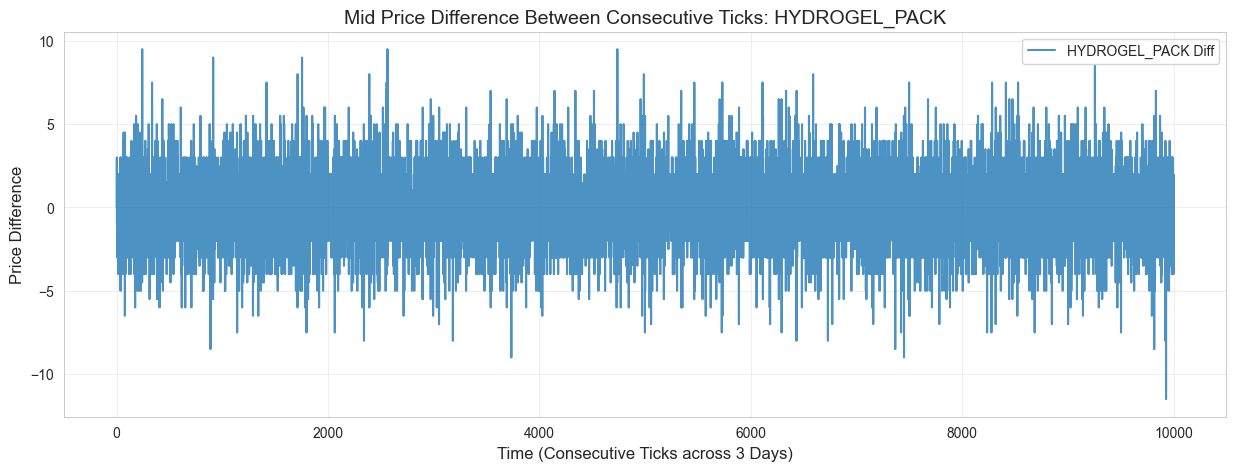

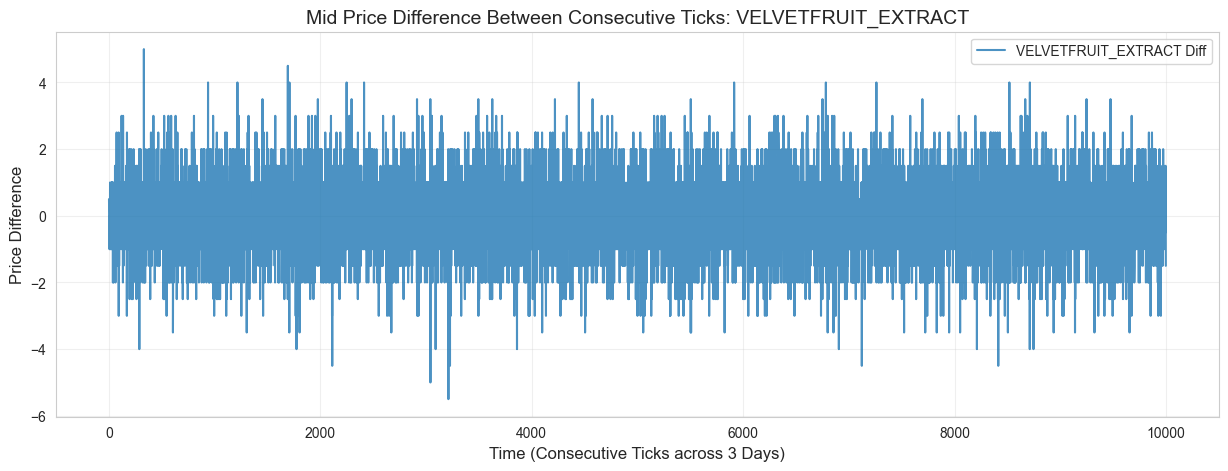

In [21]:
# To confirm: The data was strictly CONCATENATED vertically (stacked), not joined. 
# We use pd.concat() which simply appends the rows of day 0, day 1, and day 2 together.
# Here we calculate and plot the differences between consecutive timestamps (.diff())
import matplotlib.pyplot as plt

for product in ['HYDROGEL_PACK', 'VELVETFRUIT_EXTRACT']:
    # Filter directly from the main concatenated prices_df
    prod_df = prices_df[prices_df['product'] == product].copy()
    
    # We sort by day & timestamp just to guarantee perfect chronological order before taking the diff
    prod_df.sort_values(by=['day', 'timestamp'], inplace=True)
    
    # Compute the price difference from the previous consecutive timestamp
    prod_df['price_diff'] = prod_df['mid_price'].diff()
    
    plt.figure(figsize=(15, 5))
    plt.plot(range(len(prod_df)), prod_df['price_diff'], label=f'{product} Diff', alpha=0.8)
    plt.title(f'Mid Price Difference Between Consecutive Ticks: {product}', fontsize=14)
    plt.xlabel('Time (Consecutive Ticks across 3 Days)', fontsize=12)
    plt.ylabel('Price Difference', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


In [28]:
from statsmodels.tsa.stattools import acf, pacf
import plotly.graph_objects as go
from plotly.subplots import make_subplots

max_lags = 50

for product in ['HYDROGEL_PACK', 'VELVETFRUIT_EXTRACT']:
    prod_df = prices_df[prices_df['product'] == product].copy()
    prod_df.sort_values(by=['day', 'timestamp'], inplace=True)
    
    price_diff = prod_df['mid_price'].diff().dropna()
    
    acf_vals, acf_ci = acf(price_diff, nlags=max_lags, alpha=0.05)
    pacf_vals, pacf_ci = pacf(price_diff, nlags=max_lags, alpha=0.05)
    
    lags = list(range(max_lags + 1))
    
    fig = make_subplots(rows=1, cols=2, subplot_titles=[
        f'ACF - {product} (Mid Price Diff)',
        f'PACF - {product} (Mid Price Diff)'
    ])
    
    # ACF
    fig.add_trace(go.Bar(x=lags, y=acf_vals, marker_color='steelblue', name='ACF', showlegend=False), row=1, col=1)
    fig.add_trace(go.Scatter(x=lags, y=acf_ci[:, 1] - acf_vals, mode='lines', line=dict(dash='dash', color='red', width=1), name='95% CI', showlegend=False), row=1, col=1)
    fig.add_trace(go.Scatter(x=lags, y=acf_ci[:, 0] - acf_vals, mode='lines', line=dict(dash='dash', color='red', width=1), showlegend=False), row=1, col=1)
    
    # PACF
    fig.add_trace(go.Bar(x=lags, y=pacf_vals, marker_color='darkorange', name='PACF', showlegend=False), row=1, col=2)
    fig.add_trace(go.Scatter(x=lags, y=pacf_ci[:, 1] - pacf_vals, mode='lines', line=dict(dash='dash', color='red', width=1), name='95% CI', showlegend=False), row=1, col=2)
    fig.add_trace(go.Scatter(x=lags, y=pacf_ci[:, 0] - pacf_vals, mode='lines', line=dict(dash='dash', color='red', width=1), showlegend=False), row=1, col=2)
    
    fig.update_layout(
        height=450, 
        template='plotly_white',
        title_text=f'{product} — ACF & PACF of Mid Price Differences'
    )
    fig.update_xaxes(title_text='Lag')
    fig.update_yaxes(title_text='Correlation')
    
    fig.show()


In [26]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np

# Prepare both diff series
diffs = {}
for product in ['HYDROGEL_PACK', 'VELVETFRUIT_EXTRACT']:
    prod_df = prices_df[prices_df['product'] == product].copy()
    prod_df.sort_values(by=['day', 'timestamp'], inplace=True, ignore_index=True)
    diffs[product] = prod_df['mid_price'].diff().dropna().reset_index(drop=True)

hyd_diff = diffs['HYDROGEL_PACK']
vel_diff = diffs['VELVETFRUIT_EXTRACT']

# Align lengths (they should already match, but just in case)
min_len = min(len(hyd_diff), len(vel_diff))
hyd_diff = hyd_diff[:min_len]
vel_diff = vel_diff[:min_len]

# --- Cross-Correlation ---
max_lag = 100
lags = range(-max_lag, max_lag + 1)

# Normalize for Pearson cross-correlation
hyd_norm = (hyd_diff - hyd_diff.mean()) / hyd_diff.std()
vel_norm = (vel_diff - vel_diff.mean()) / vel_diff.std()

xcorr = []
for lag in lags:
    if lag >= 0:
        corr = np.mean(hyd_norm[lag:].values * vel_norm[:min_len - lag].values)
    else:
        corr = np.mean(hyd_norm[:min_len + lag].values * vel_norm[-lag:].values)
    xcorr.append(corr)

# 95% confidence interval
conf = 1.96 / np.sqrt(min_len)

# --- Plotly Cross-Correlation Plot ---
fig = go.Figure()

fig.add_trace(go.Bar(
    x=list(lags),
    y=xcorr,
    name='Cross-Correlation',
    marker_color='steelblue'
))

fig.add_hline(y=conf, line_dash='dash', line_color='red', annotation_text='95% CI')
fig.add_hline(y=-conf, line_dash='dash', line_color='red')
fig.add_hline(y=0, line_color='gray', line_width=0.5)

fig.update_layout(
    title='Cross-Correlation: HYDROGEL_PACK vs VELVETFRUIT_EXTRACT (Mid Price Diff)',
    xaxis_title='Lag (positive = Hydrogel leads Velvetfruit)',
    yaxis_title='Correlation',
    template='plotly_white',
    height=500
)

fig.show()

# --- Print top significant lags ---
xcorr_df = pd.DataFrame({'lag': list(lags), 'xcorr': xcorr})
xcorr_df['significant'] = xcorr_df['xcorr'].abs() > conf
significant = xcorr_df[xcorr_df['significant']].sort_values('xcorr', key=abs, ascending=False)

print(f"\n95% confidence threshold: ±{conf:.6f}")
print(f"\nTop 20 significant lags:")
print(significant.head(20).to_string(index=False))



95% confidence threshold: ±0.019601

Top 20 significant lags:
 lag     xcorr  significant
 -84  0.026219         True
 -43 -0.026199         True
  -3  0.026084         True
  47 -0.025229         True
 -53  0.025184         True
  -5  0.024826         True
  24  0.024527         True
  25 -0.024245         True
  83 -0.023370         True
  88 -0.022838         True
 -92 -0.022709         True
 -15 -0.020263         True
